# 03 · RFM Customer Segmentation

This notebook is about "who are our best customers?". RFM scores every registered customer on three things:

- **Recency**: how many days since their last order (lower is better)
- **Frequency**: how many separate orders they've placed
- **Monetary**: how much they've spent in total

Each one is scored 1 to 5 by quintile, and the scores are then mapped to eight segments the
marketing team can act on. Guest orders are left out because there's no customer to score.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from style import BLUE, ORANGE, GREY, DARK_BLUE, TEXT_MUTED, GBP, set_style, save_fig, titles

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)

df = pd.read_csv("../data/processed/clean.csv", parse_dates=["InvoiceDate"], dtype={"Invoice": str, "StockCode": str})
df["CustomerID"] = df["CustomerID"].astype(int)
print(f"{df.CustomerID.nunique():,} customers, {df.Invoice.nunique():,} orders, £{df.Revenue.sum():,.0f} revenue")

5,839 customers, 36,329 orders, £16,467,060 revenue


## 1. Recency, Frequency, Monetary

The snapshot date is the day after the last invoice in the data, so a customer who ordered on the
final day gets a recency of 1.

In [2]:
snapshot = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot.date())

rfm = df.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
)
rfm["Recency"] = (snapshot - rfm["LastPurchase"].dt.normalize()).dt.days
rfm = rfm[["Recency", "Frequency", "Monetary"]]
rfm.describe(percentiles=[0.2, 0.4, 0.5, 0.6, 0.8]).T

Snapshot date: 2011-12-10


,count,mean,std,min,20%,40%,50%,60%,80%,max
Recency,"5,839.00",200.91,208.61,1.00,20.00,59.00,96.00,187.00,409.00,739.00
Frequency,"5,839.00",6.22,12.63,1.00,1.00,2.00,3.00,4.00,8.00,369.00
Monetary,"5,839.00","2,820.18","13,875.96",2.90,280.83,596.04,851.01,"1,192.82","2,863.17","579,128.64"


Frequency is heavily skewed. More than a quarter of customers have exactly one order, which is why
`pd.qcut` can't split it into five bins on its own: the bin edges collide. Ranking with
`method="first"` breaks ties by order of appearance, so every quintile ends up the same size.

In [3]:
print(f"Customers with a single order: {(rfm.Frequency == 1).mean():.1%}")


def quintile_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    """Score a metric 1-5 by quintile. Ties are broken by rank(method="first")."""
    labels = [1, 2, 3, 4, 5] if higher_is_better else [5, 4, 3, 2, 1]
    return pd.qcut(series.rank(method="first"), q=5, labels=labels).astype(int)


rfm["R"] = quintile_score(rfm["Recency"], higher_is_better=False)
rfm["F"] = quintile_score(rfm["Frequency"])
rfm["M"] = quintile_score(rfm["Monetary"])
rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

# Sanity check: each score should hold ~20% of customers, and the raw metric should move in step with it
rfm.groupby("R").agg(Customers=("Recency", "size"), MinRecency=("Recency", "min"), MaxRecency=("Recency", "max"))

Customers with a single order: 27.6%


,Customers,MinRecency,MaxRecency
R,,,
1,1168,409,739
2,1168,187,409
3,1167,59,187
4,1168,20,59
5,1168,1,20


## 2. Map scores to segments

I use the recency score plus the average of the frequency and monetary scores (call it FM).
Frequency and spend go together closely here (people who order often spend more), so averaging
them keeps the rules simple. The rules run top to bottom and each customer gets the first one that
matches:

| Segment | Rule | In plain English |
|---|---|---|
| Champions | R ≥ 4 and FM ≥ 4 | Bought recently, buy often, spend the most |
| Loyal | R ≥ 3 and FM ≥ 3 | Regular, solid spenders |
| New Customers | R ≥ 4 and F = 1 | First order was recent |
| Potential Loyalists | R ≥ 4 (rest) | Recent, a few orders, could grow |
| Can't Lose Them | R ≤ 2 and FM ≥ 4 | Used to be top customers, gone quiet |
| At Risk | R ≤ 2 and FM ≥ 2.5 | Decent customers drifting away |
| Lost | R = 1 (rest) | Low value and long gone |
| Hibernating | everything else | Low value, not recent |

In [4]:
SEGMENT_ORDER = ["Champions", "Loyal", "Potential Loyalists", "New Customers",
                 "At Risk", "Can't Lose Them", "Hibernating", "Lost"]

# Three colour groups keep the charts readable: best customers, slipping high-value customers, everyone else
SEGMENT_GROUP = {
    "Champions": "Best", "Loyal": "Best",
    "At Risk": "Slipping", "Can't Lose Them": "Slipping",
    "Potential Loyalists": "Other", "New Customers": "Other", "Hibernating": "Other", "Lost": "Other",
}
GROUP_COLOR = {"Best": BLUE, "Slipping": ORANGE, "Other": GREY}
SEGMENT_COLOR = {s: GROUP_COLOR[g] for s, g in SEGMENT_GROUP.items()}


def assign_segment(rfm: pd.DataFrame) -> pd.Series:
    """Map R, F and M scores to a named segment (first matching rule wins)."""
    r, f = rfm["R"], rfm["F"]
    fm = (rfm["F"] + rfm["M"]) / 2
    conditions = [
        (r >= 4) & (fm >= 4),
        (r >= 3) & (fm >= 3),
        (r >= 4) & (f == 1),
        (r >= 4),
        (r <= 2) & (fm >= 4),
        (r <= 2) & (fm >= 2.5),
        (r == 1),
    ]
    choices = ["Champions", "Loyal", "New Customers", "Potential Loyalists",
               "Can't Lose Them", "At Risk", "Lost"]
    return pd.Series(np.select(conditions, choices, default="Hibernating"), index=rfm.index)


rfm["Segment"] = pd.Categorical(assign_segment(rfm), categories=SEGMENT_ORDER, ordered=True)
rfm.to_csv("../data/processed/rfm_segments.csv")
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
CustomerID,,,,,,,,
12346,530,2,169.36,1,2,1,121,Lost
12347,3,8,"4,921.53",5,4,5,545,Champions
12348,76,5,"1,658.40",3,4,4,344,Loyal
12349,19,3,"3,678.69",5,3,5,535,Champions
12350,311,1,294.40,2,1,2,212,Hibernating


In [5]:
seg = rfm.groupby("Segment", observed=False).agg(
    Customers=("Recency", "size"),
    Revenue=("Monetary", "sum"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean"),
)
seg["% Customers"] = seg.Customers / seg.Customers.sum() * 100
seg["% Revenue"] = seg.Revenue / seg.Revenue.sum() * 100
seg.round(1)

,Customers,Revenue,AvgRecency,AvgFrequency,AvgMonetary,% Customers,% Revenue
Segment,,,,,,,
Champions,1301,"11,473,064.30",20.20,16.70,"8,818.70",22.30,69.70
Loyal,1206,"2,509,706.80",73.60,5.70,"2,081.00",20.70,15.20
Potential Loyalists,392,"178,736.90",27.20,2.10,456.00,6.70,1.10
New Customers,167,"50,552.20",30.20,1.00,302.70,2.90,0.30
At Risk,715,"744,869.00",384.90,3.00,"1,041.80",12.20,4.50
Can't Lose Them,247,"952,617.40",344.40,8.70,"3,856.80",4.20,5.80
Hibernating,992,"341,249.00",225.70,1.40,344.00,17.00,2.10
Lost,819,"216,263.90",559.50,1.20,264.10,14.00,1.30


## 3. Segment sizes

saved 06_rfm_segment_sizes.png


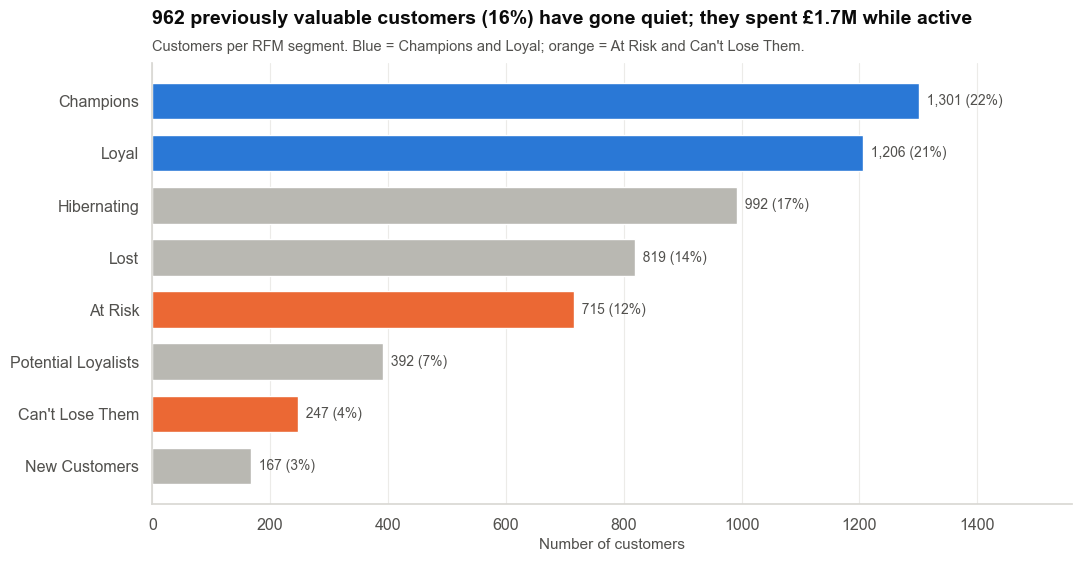

In [6]:
by_size = seg.sort_values("Customers")
fig, ax = plt.subplots(figsize=(11, 5.8))
ax.barh(by_size.index.astype(str), by_size.Customers, color=[SEGMENT_COLOR[s] for s in by_size.index], height=0.7)
for i, (n, p) in enumerate(zip(by_size.Customers, by_size["% Customers"])):
    ax.text(n, i, f"  {n:,} ({p:.0f}%)", va="center", fontsize=10, color=TEXT_MUTED)
ax.set_xlim(0, by_size.Customers.max() * 1.2)
ax.set_xlabel("Number of customers")
ax.grid(axis="y", visible=False)

slipping = seg.loc[["At Risk", "Can't Lose Them"]]
titles(ax, f"{slipping.Customers.sum():,} previously valuable customers ({slipping['% Customers'].sum():.0f}%) have gone quiet; "
           f"they spent £{slipping.Revenue.sum() / 1e6:.1f}M while active",
       "Customers per RFM segment. Blue = Champions and Loyal; orange = At Risk and Can't Lose Them.")
fig.tight_layout()
save_fig(fig, "06_rfm_segment_sizes")
plt.show()

## 4. Who brings in the revenue?

saved 07_rfm_revenue_share.png


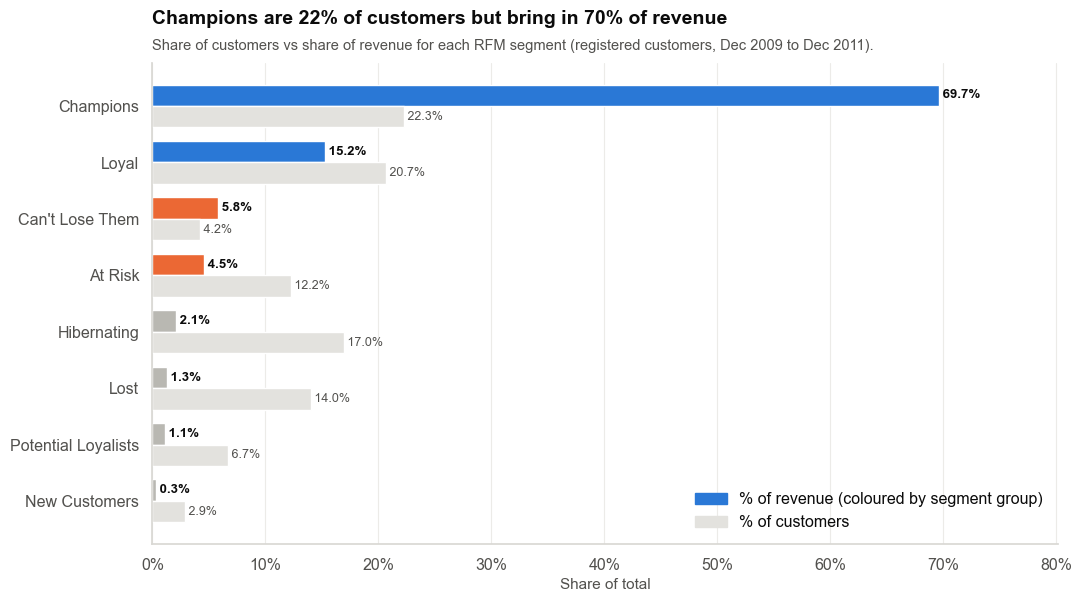

In [7]:
share = seg[["% Customers", "% Revenue"]].sort_values("% Revenue")
y = np.arange(len(share))

fig, ax = plt.subplots(figsize=(11, 6.2))
ax.barh(y + 0.19, share["% Revenue"], height=0.38, color=[SEGMENT_COLOR[s] for s in share.index], label="% of revenue")
ax.barh(y - 0.19, share["% Customers"], height=0.38, color="#e3e2de", label="% of customers")
for i, (c, r) in enumerate(zip(share["% Customers"], share["% Revenue"])):
    ax.text(r, i + 0.19, f" {r:.1f}%", va="center", fontsize=9.5, fontweight="bold")
    ax.text(c, i - 0.19, f" {c:.1f}%", va="center", fontsize=9, color=TEXT_MUTED)
ax.set_yticks(y, share.index.astype(str))
ax.set_xlim(0, share.values.max() * 1.15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Share of total")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", handles=[
    plt.Rectangle((0, 0), 1, 1, color=BLUE, label="% of revenue (coloured by segment group)"),
    plt.Rectangle((0, 0), 1, 1, color="#e3e2de", label="% of customers"),
])

champ = seg.loc["Champions"]
titles(ax, f"Champions are {champ['% Customers']:.0f}% of customers but bring in {champ['% Revenue']:.0f}% of revenue",
       "Share of customers vs share of revenue for each RFM segment (registered customers, Dec 2009 to Dec 2011).")
fig.tight_layout()
save_fig(fig, "07_rfm_revenue_share")
plt.show()

## 5. RFM scatter

Each dot is a customer. Both axes use a log scale because a handful of wholesale accounts
have hundreds of orders.

saved 08_rfm_scatter.png


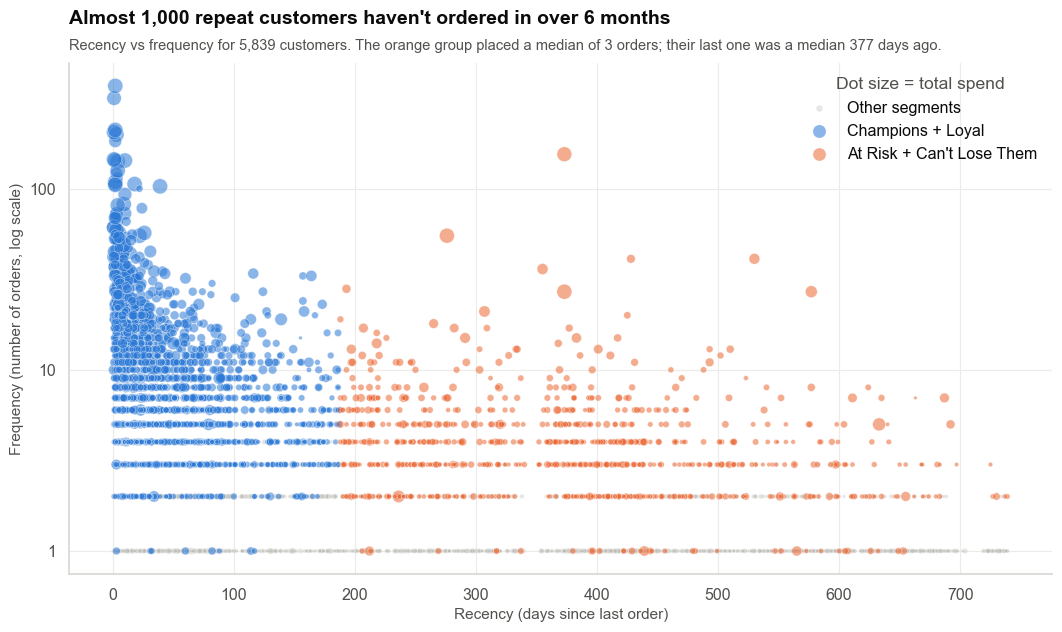

In [8]:
plot_df = rfm.assign(Group=rfm.Segment.map(SEGMENT_GROUP).astype(str))
group_labels = {"Best": "Champions + Loyal", "Slipping": "At Risk + Can't Lose Them", "Other": "Other segments"}

fig, ax = plt.subplots(figsize=(11, 6.5))
for group in ["Other", "Best", "Slipping"]:        # draw grey first so it sits underneath
    g = plot_df[plot_df.Group == group]
    ax.scatter(g.Recency, g.Frequency, s=np.clip(np.sqrt(g.Monetary.clip(lower=1)) / 2, 6, 120),
               color=GROUP_COLOR[group], alpha=0.55 if group != "Other" else 0.35,
               edgecolor="white", linewidth=0.4, label=group_labels[group])
ax.set_yscale("log")
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Frequency (number of orders, log scale)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
leg = ax.legend(loc="upper right", title="Dot size = total spend", markerscale=1.2)
leg.get_title().set_color(TEXT_MUTED)

slip = plot_df[plot_df.Group == "Slipping"]
titles(ax, f"Almost 1,000 repeat customers haven't ordered in over {slip.Recency.min() // 30} months",
       f"Recency vs frequency for {len(rfm):,} customers. The orange group placed a median of "
       f"{slip.Frequency.median():.0f} orders; their last one was a median {slip.Recency.median():.0f} days ago.")
fig.tight_layout()
save_fig(fig, "08_rfm_scatter")
plt.show()

## 6. Pareto: how concentrated is revenue?

In [9]:
spend = rfm["Monetary"].sort_values(ascending=False).to_numpy()
cum_revenue = spend.cumsum() / spend.sum()
cum_customers = np.arange(1, len(spend) + 1) / len(spend)

top20_idx = int(np.ceil(0.2 * len(spend))) - 1
top20_share = cum_revenue[top20_idx]
top1_share = cum_revenue[int(np.ceil(0.01 * len(spend))) - 1]
half_idx = np.searchsorted(cum_revenue, 0.5)
print(f"Top 20% of customers ({top20_idx + 1:,}) = {top20_share:.1%} of revenue")
print(f"Top 1% of customers = {top1_share:.1%} of revenue")
print(f"Half of all revenue comes from the top {cum_customers[half_idx]:.1%} of customers ({half_idx + 1:,} people)")

Top 20% of customers (1,168) = 76.7% of revenue
Top 1% of customers = 31.1% of revenue
Half of all revenue comes from the top 4.7% of customers (274 people)


saved 09_pareto_revenue.png


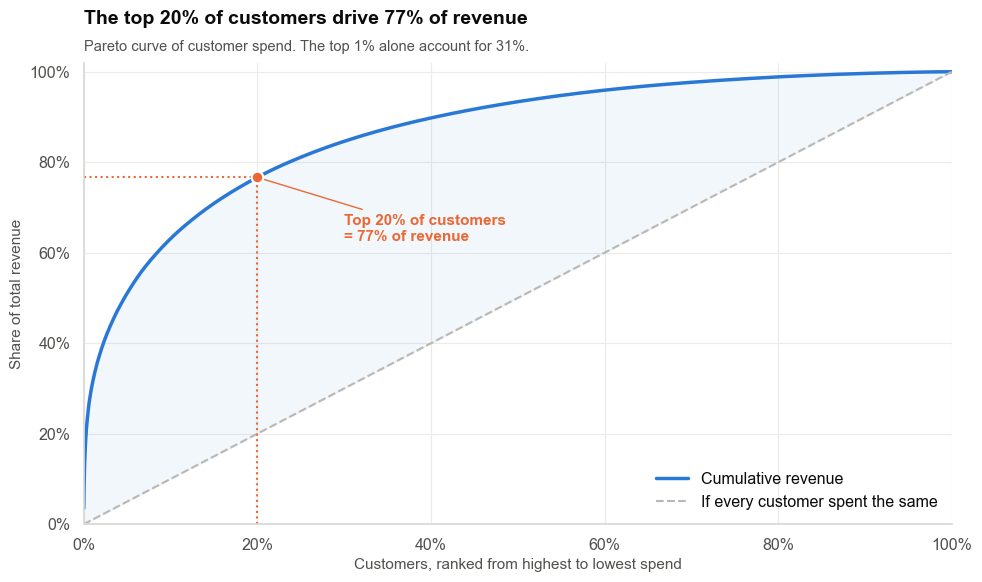

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cum_customers * 100, cum_revenue * 100, color=BLUE, lw=2.5, label="Cumulative revenue")
ax.plot([0, 100], [0, 100], color=GREY, ls="--", lw=1.5, label="If every customer spent the same")
ax.fill_between(cum_customers * 100, cum_revenue * 100, cum_customers * 100, color=BLUE, alpha=0.06)

ax.plot([20, 20], [0, top20_share * 100], color=ORANGE, lw=1.5, ls=":")
ax.plot([0, 20], [top20_share * 100, top20_share * 100], color=ORANGE, lw=1.5, ls=":")
ax.scatter([20], [top20_share * 100], color=ORANGE, s=70, zorder=5, edgecolor="white", linewidth=1.5)
ax.annotate(f"Top 20% of customers\n= {top20_share:.0%} of revenue", (20, top20_share * 100),
            xytext=(30, top20_share * 100 - 14), fontsize=11, fontweight="bold", color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, lw=1))

ax.set_xlim(0, 100)
ax.set_ylim(0, 102)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Customers, ranked from highest to lowest spend")
ax.set_ylabel("Share of total revenue")
ax.legend(loc="lower right")
titles(ax, f"The top 20% of customers drive {top20_share:.0%} of revenue",
       f"Pareto curve of customer spend. The top 1% alone account for {top1_share:.0%}.")
fig.tight_layout()
save_fig(fig, "09_pareto_revenue")
plt.show()

## 7. What to do with each segment

The actions below are matched to how each segment actually behaves (the averages in the table).

In [11]:
ACTIONS = {
    "Champions": "Early access to new ranges and a named account contact. Ask for reviews and referrals. Don't discount them; they already buy.",
    "Loyal": "Volume-tier pricing and cross-sell from adjacent product lines to move them up to Champion.",
    "Potential Loyalists": "Follow up the next order with a bundle offer or free delivery threshold to build a habit.",
    "New Customers": "Welcome series: best sellers, reorder reminder around the typical gap between orders.",
    "At Risk": "Personal win-back email with a time-limited offer, ideally before the Sep-Nov peak.",
    "Can't Lose Them": "Phone call or account-manager outreach. Find out why they stopped; these are high-value accounts.",
    "Hibernating": "Low-cost reactivation only: include them in seasonal campaigns, nothing personalised.",
    "Lost": "One last re-engagement email, then suppress from paid campaigns to save budget.",
}

actions = seg.assign(Action=seg.index.map(ACTIONS))[
    ["Customers", "% Customers", "% Revenue", "AvgRecency", "AvgFrequency", "AvgMonetary", "Action"]]
actions.columns = ["Customers", "% of customers", "% of revenue", "Avg days since last order",
                   "Avg orders", "Avg spend (£)", "Recommended action"]
(actions.style
    .format({"Customers": "{:,}", "% of customers": "{:.1f}%", "% of revenue": "{:.1f}%",
             "Avg days since last order": "{:.0f}", "Avg orders": "{:.1f}", "Avg spend (£)": "£{:,.0f}"})
    .set_properties(subset=["Recommended action"], **{"text-align": "left", "white-space": "normal", "min-width": "320px"}))

,Customers,% of customers,% of revenue,Avg days since last order,Avg orders,Avg spend (£),Recommended action
Segment,,,,,,,
Champions,"1,301",22.3%,69.7%,20,16.7,"£8,819",Early access to new ranges and a named account contact. Ask for reviews and referrals. Don't discount them; they already buy.
Loyal,"1,206",20.7%,15.2%,74,5.7,"£2,081",Volume-tier pricing and cross-sell from adjacent product lines to move them up to Champion.
Potential Loyalists,392,6.7%,1.1%,27,2.1,£456,Follow up the next order with a bundle offer or free delivery threshold to build a habit.
New Customers,167,2.9%,0.3%,30,1.0,£303,"Welcome series: best sellers, reorder reminder around the typical gap between orders."
At Risk,715,12.2%,4.5%,385,3.0,"£1,042","Personal win-back email with a time-limited offer, ideally before the Sep-Nov peak."
Can't Lose Them,247,4.2%,5.8%,344,8.7,"£3,857",Phone call or account-manager outreach. Find out why they stopped; these are high-value accounts.
Hibernating,992,17.0%,2.1%,226,1.4,£344,"Low-cost reactivation only: include them in seasonal campaigns, nothing personalised."
Lost,819,14.0%,1.3%,559,1.2,£264,"One last re-engagement email, then suppress from paid campaigns to save budget."


In [12]:
# Revenue at stake: what the slipping segments spent while they were active
at_stake = seg.loc[["At Risk", "Can't Lose Them"]]
print(f"At Risk + Can't Lose Them: {at_stake.Customers.sum():,} customers, "
      f"£{at_stake.Revenue.sum():,.0f} lifetime revenue ({at_stake['% Revenue'].sum():.1f}% of total)")
print(f"Champions: {seg.loc['Champions', 'Customers']:,} customers, avg spend £{seg.loc['Champions', 'AvgMonetary']:,.0f}, "
      f"avg {seg.loc['Champions', 'AvgFrequency']:.1f} orders")

At Risk + Can't Lose Them: 962 customers, £1,697,486 lifetime revenue (10.3% of total)
Champions: 1,301 customers, avg spend £8,819, avg 16.7 orders


## Key Takeaways

- **Revenue is very concentrated.** The top 20% of customers bring in **76.7%** of revenue and the top 1% (59 customers) bring in **31.1%**. Half of all revenue comes from just **274 customers**.
- **Champions are 1,301 customers (22%) and bring in 69.7% of revenue.** They average £8,819 in spend and 16.7 orders, and last ordered about 20 days ago on average. Protecting this group matters more than anything else on this list.
- **962 previously valuable customers have gone quiet** (At Risk + Can't Lose Them). Together they spent **£1.70M (10.3% of revenue)**, and none of them has ordered in at least six months.
- **The 247 "Can't Lose Them" customers are the most urgent.** They average £3,857 and 8.7 orders each but haven't bought for an average of 344 days. They're few enough to call one by one.
- **Loyal customers (1,206) are the best upgrade pool.** They're 21% of customers and 15.2% of revenue at £2,081 each, about a quarter of what a Champion spends.
- **27.6% of customers have only ever placed one order.** Hibernating and Lost together are 31% of customers but only 3.4% of revenue, so expensive campaigns aimed at them are unlikely to pay back.